In [3]:
!pip -q install transformers
!pip -q install accelerate
!pip -q install av
!pip -q install librosa
!pip -q install soundfile
!pip -q install ffmpeg-python
!pip -q install timm

In [4]:
import os
import cv2
import av
import torch
import librosa
import numpy as np
import pandas as pd
import ffmpeg

from pathlib import Path
from tqdm.auto import tqdm

from transformers import (
    VideoMAEImageProcessor,
    VideoMAEModel,
    Wav2Vec2Processor,
    Wav2Vec2Model,
)

In [5]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

NUM_FRAMES = 16
IMAGE_SIZE = 224

SAMPLE_RATE = 16000
MAX_AUDIO_SECONDS = 5

print("Device :", DEVICE)

Device : cuda


In [6]:
DATASET_PATH = Path(
    "/kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/FakeAVCeleb_v1.2"
)

print(DATASET_PATH.exists())

True


In [7]:
video_paths = []
labels = []

for video in DATASET_PATH.rglob("*.mp4"):

    path = str(video)

    if "RealVideo-RealAudio" in path:
        label = 0
    else:
        label = 1

    video_paths.append(path)
    labels.append(label)

print("Total Videos :", len(video_paths))
print("Real :", labels.count(0))
print("Fake :", labels.count(1))

print("\nSample Videos:")
for p, l in zip(video_paths[:10], labels[:10]):
    print(l, p)

Total Videos : 21560
Real : 500
Fake : 21060

Sample Videos:
1 /kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/men/id00391/00052_id00173_wavtolip.mp4
1 /kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/men/id00391/00052_id00166_PQV2ZbJBLNk_id00478_wavtolip.mp4
1 /kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/men/id00391/00052_id01530_wavtolip.mp4
1 /kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/men/id00391/00052_id01236_7WdumGR5-JM_id02051_wavtolip.mp4
1 /kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/men/id00391/00052_id00476_UgdYVJ6xPYg_faceswap_id02342_wavtolip.mp4
1 /kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/men/id00391/000

In [8]:
import random

random.seed(42)

real_videos = []
fake_videos = []

for video in DATASET_PATH.rglob("*.mp4"):

    path = str(video)

    if "RealVideo-RealAudio" in path:
        real_videos.append(path)
    else:
        fake_videos.append(path)

print("Original")
print("Real :", len(real_videos))
print("Fake :", len(fake_videos))

# Randomly sample fake videos
fake_videos = random.sample(fake_videos, len(real_videos))

video_paths = real_videos + fake_videos
labels = [0]*len(real_videos) + [1]*len(fake_videos)

# Shuffle
combined = list(zip(video_paths, labels))
random.shuffle(combined)

video_paths, labels = zip(*combined)

video_paths = list(video_paths)
labels = list(labels)

print("\nBalanced Dataset")
print("Total :", len(video_paths))
print("Real :", labels.count(0))
print("Fake :", labels.count(1))

Original
Real : 500
Fake : 21060

Balanced Dataset
Total : 1000
Real : 500
Fake : 500


In [9]:
############################################
# Frame Extraction
############################################

def extract_frames(video_path, num_frames=16):

    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        cap.release()
        return None

    frame_indices = np.linspace(
        0,
        total_frames - 1,
        num_frames,
        dtype=int
    )

    frames = []

    for idx in frame_indices:

        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)

        success, frame = cap.read()

        if not success:
            continue

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, (224,224))

        frames.append(frame)

    cap.release()

    if len(frames) != num_frames:
        return None

    return frames

In [10]:
sample_frames = extract_frames(video_paths[0])

print("Number of Frames :", len(sample_frames))

print("Frame Shape :", sample_frames[0].shape)

Number of Frames : 16
Frame Shape : (224, 224, 3)


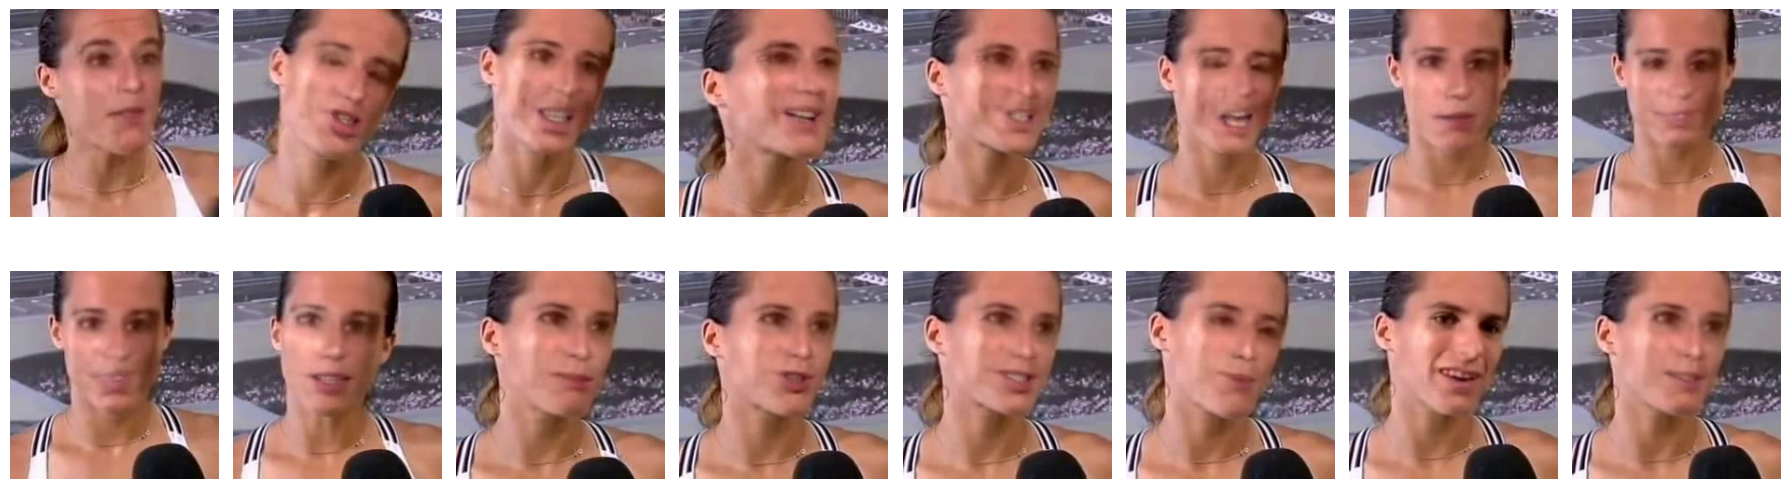

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,6))

for i in range(16):

    plt.subplot(2,8,i+1)

    plt.imshow(sample_frames[i])

    plt.axis("off")

plt.tight_layout()

plt.show()

In [12]:
############################################
# Load VideoMAE
############################################

from transformers import VideoMAEImageProcessor, VideoMAEModel

processor = VideoMAEImageProcessor.from_pretrained(
    "MCG-NJU/videomae-base"
)

videomae = VideoMAEModel.from_pretrained(
    "MCG-NJU/videomae-base"
)

videomae.to(DEVICE)
videomae.eval()

print("✅ VideoMAE Loaded Successfully")

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/725 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/377M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/184 [00:00<?, ?it/s]

VideoMAEModel LOAD REPORT from: MCG-NJU/videomae-base
Key                                                                  | Status     |  | 
---------------------------------------------------------------------+------------+--+-
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_after.bias             | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_before.weight          | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.output.dense.weight              | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.output.dense.bias                | UNEXPECTED |  | 
decoder.head.weight                                                  | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.output.dense.weight    | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.key.weight   | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.intermediate.dense.bias          | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.query.weig

✅ VideoMAE Loaded Successfully


In [13]:
############################################
# Video Feature Extraction
############################################

@torch.no_grad()
def extract_video_embedding(frames):

    inputs = processor(
        frames,
        return_tensors="pt"
    )

    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    outputs = videomae(**inputs)

    embedding = outputs.last_hidden_state.mean(dim=1)

    return embedding.squeeze().cpu().numpy()

In [14]:
video_embedding = extract_video_embedding(sample_frames)

print("Embedding Shape :", video_embedding.shape)

Embedding Shape : (768,)


In [16]:
############################################
# Extract Video Features
############################################

video_features = []

for video in tqdm(video_paths):

    frames = extract_frames(video)

    if frames is None:
        video_features.append(np.zeros(768))
        continue

    feature = extract_video_embedding(frames)

    video_features.append(feature)

video_features = np.array(video_features)

print(video_features.shape)

  0%|          | 0/1000 [00:00<?, ?it/s]

(1000, 768)


In [17]:
np.save("video_features.npy", video_features)

print("✅ Video Features Saved")

✅ Video Features Saved


In [18]:
############################################
# Audio Extraction
############################################

import tempfile
import soundfile as sf

def extract_audio(video_path, sr=16000, duration=5):

    with tempfile.NamedTemporaryFile(suffix=".wav", delete=True) as temp_audio:

        (
            ffmpeg
            .input(video_path)
            .output(
                temp_audio.name,
                ac=1,
                ar=sr,
                format='wav'
            )
            .overwrite_output()
            .run(quiet=True)
        )

        audio, _ = librosa.load(
            temp_audio.name,
            sr=sr
        )

    max_length = sr * duration

    if len(audio) > max_length:
        audio = audio[:max_length]

    else:
        audio = np.pad(
            audio,
            (0, max_length-len(audio))
        )

    return audio

In [19]:
audio = extract_audio(video_paths[0])

print(audio.shape)

(80000,)


In [20]:
############################################
# Load Wav2Vec2
############################################

processor_audio = Wav2Vec2Processor.from_pretrained(
    "facebook/wav2vec2-base"
)

wav2vec = Wav2Vec2Model.from_pretrained(
    "facebook/wav2vec2-base"
)

wav2vec.to(DEVICE)
wav2vec.eval()

print("✅ Wav2Vec2 Loaded")

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Wav2Vec2 Loaded


In [21]:
############################################
# Extract Audio Embedding
############################################

@torch.no_grad()

def extract_audio_embedding(audio):

    inputs = processor_audio(
        audio,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )

    inputs = {
        k:v.to(DEVICE)
        for k,v in inputs.items()
    }

    outputs = wav2vec(**inputs)

    embedding = outputs.last_hidden_state.mean(dim=1)

    return embedding.squeeze().cpu().numpy()

In [22]:
audio_embedding = extract_audio_embedding(audio)

print(audio_embedding.shape)

(768,)


In [23]:
############################################
# Extract Audio Features
############################################

audio_features = []

for video in tqdm(video_paths):

    audio = extract_audio(video)

    feature = extract_audio_embedding(audio)

    audio_features.append(feature)

audio_features = np.array(audio_features)

print(audio_features.shape)

  0%|          | 0/1000 [00:00<?, ?it/s]

(1000, 768)


In [24]:
############################################
# Save Features
############################################

np.save("video_features.npy", video_features)
np.save("audio_features.npy", audio_features)
np.save("labels.npy", np.array(labels))
np.save("video_names.npy", np.array(video_paths))

print("✅ Everything Saved Successfully")

✅ Everything Saved Successfully
